### 课程一（15%）

##### 1.环境配置

编译器安装:Visual Studio Code/Pycharm

Python环境管理:Python虚拟环境搭建(conda/venv),推荐安装anaconda/miniconda进行环境管理

https://blog.csdn.net/ming12131342/article/details/140233867

验证安装，终端运行 `conda --version`

换源：[ubuntu、conda、pip 换北外源（北京外国语大学开源软件镜像站）_北外临时源-CSDN博客](https://blog.csdn.net/weixin_43667077/article/details/108282523)

创建虚拟环境

`conda create -n speech_env python=3.8 `

`conda activate speech_env`

##### 2.安装numpy,matplotlib,librosa,pandas

In [ ]:
%pip install numpy matplotlib librosa pandas

##### 3.导入librosa,pandas,numpy,matplotlib,IPython

In [1]:
import librosa  
import matplotlib.pyplot as plt  
import IPython.display as ipd
import pandas as pd
import numpy as np

##### 4.使用IPython展示音频

In [2]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)

##### 5.使用librosa加载音频,打印加载的音频shape,音频采样率

In [3]:
y, sr = librosa.load(audio_file)
print(type(y))
print(f'shape y: {y.shape}')
print(f'sr: {sr}')

<class 'numpy.ndarray'>
shape y: (99485,)
sr: 22050


##### 6.使用matplotlib包绘制音频

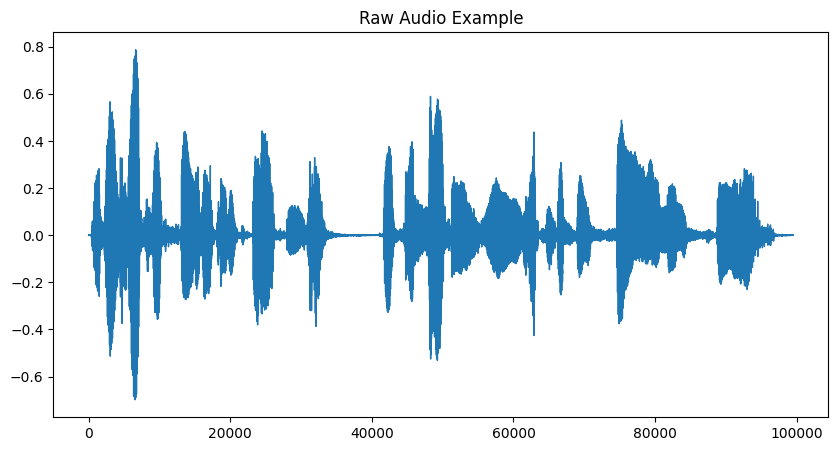

In [4]:
#序列化音频数据
pd.Series(y).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 7.使用librosa计算音频的幅度谱图,打印幅度谱shape并使用matplotlib进行绘制

(1025, 195)


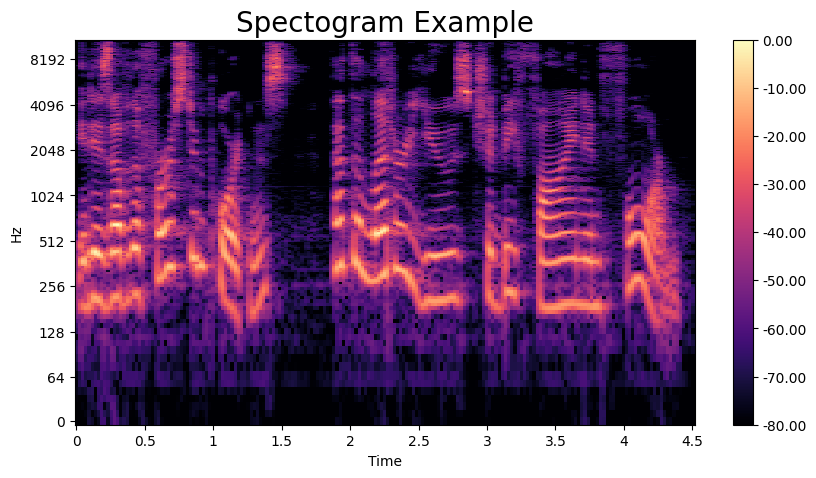

In [5]:
#把加载的音频通过短时傅里叶变换
D = librosa.stft(y)
#取复数矩阵的模,得到幅度
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
print(S_db.shape)

# Plot the transformed audio data
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(S_db,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

##### 8.使用librosa计算并绘制mel谱

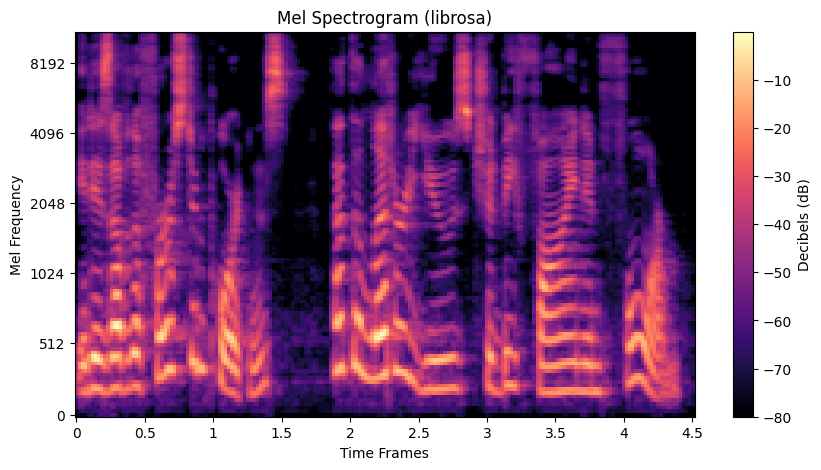

In [6]:
n_fft = 2048       # FFT 大小
hop_length = 512   # 帧移
n_mels = 128       # Mel 频带数
mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 5))
librosa.display.specshow(mel_spec_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (librosa)")
plt.show()

##### 9.安装torch,torchaudio
https://pytorch.org/

GPU环境搭建：

https://blog.csdn.net/2501_91798322/article/details/154492010

In [ ]:
%pip install torch torchaudio

In [7]:
import torch, torchaudio
print(torch.__version__)
print(torch.cuda.is_available()) 

2.2.0
True


##### 10.使用torchaudio加载音频,计算mel谱并绘制

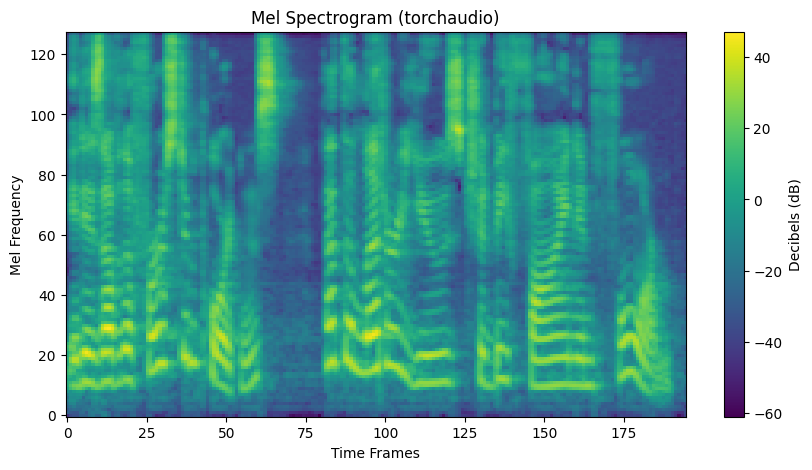

In [8]:
import torchaudio
import torchaudio.transforms as T
import matplotlib.pyplot as plt
waveform, sample_rate = torchaudio.load("LJ001-0011.wav") 

n_fft = 2048  
n_mels = 128   
hop_length = 512  

# TODO：调用函数计算 Mel 频谱图
mel_transform = T.MelSpectrogram(
sample_rate=sample_rate,
n_fft=n_fft,
hop_length=hop_length,
n_mels=n_mels,
power=2.0,
)
mel_spec = mel_transform(waveform)
to_db = T.AmplitudeToDB(stype="power")
mel_spec_db = to_db(mel_spec)
plt.figure(figsize=(10, 5))
plt.imshow(mel_spec_db[0].numpy(), aspect="auto", origin="lower")
plt.colorbar(label="Decibels (dB)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency")
plt.title("Mel Spectrogram (torchaudio)")
plt.show()

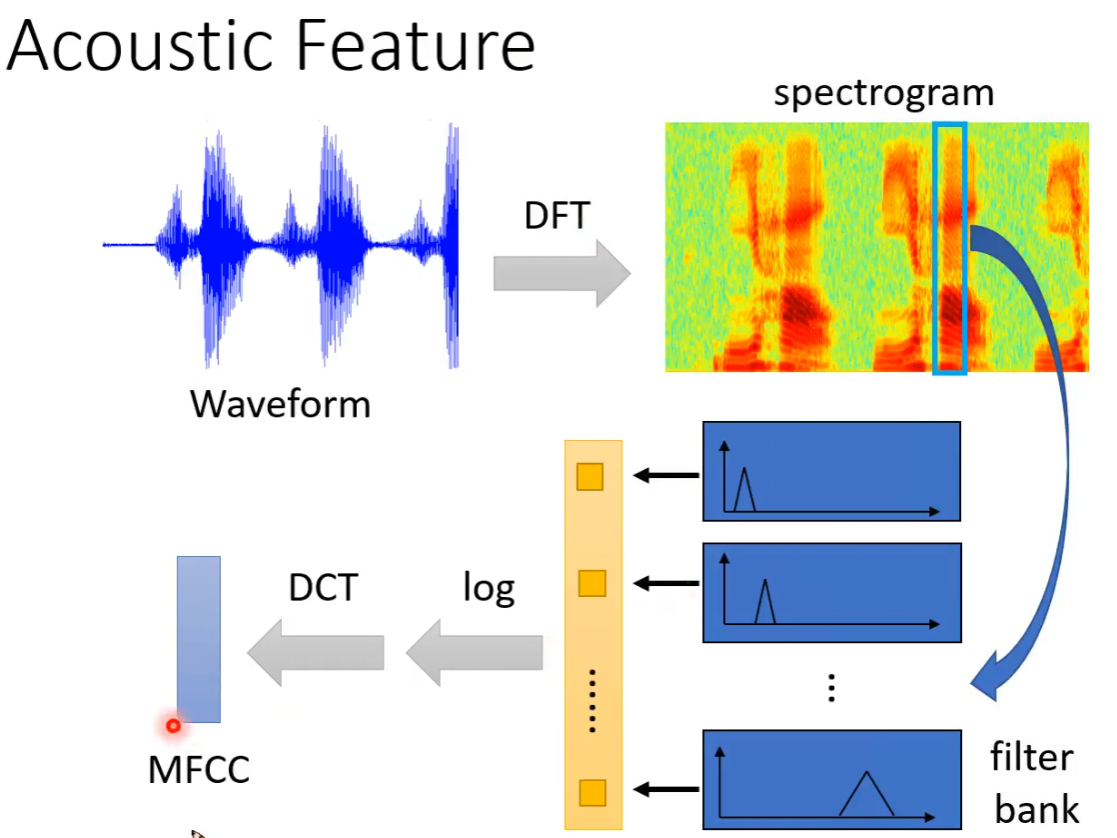
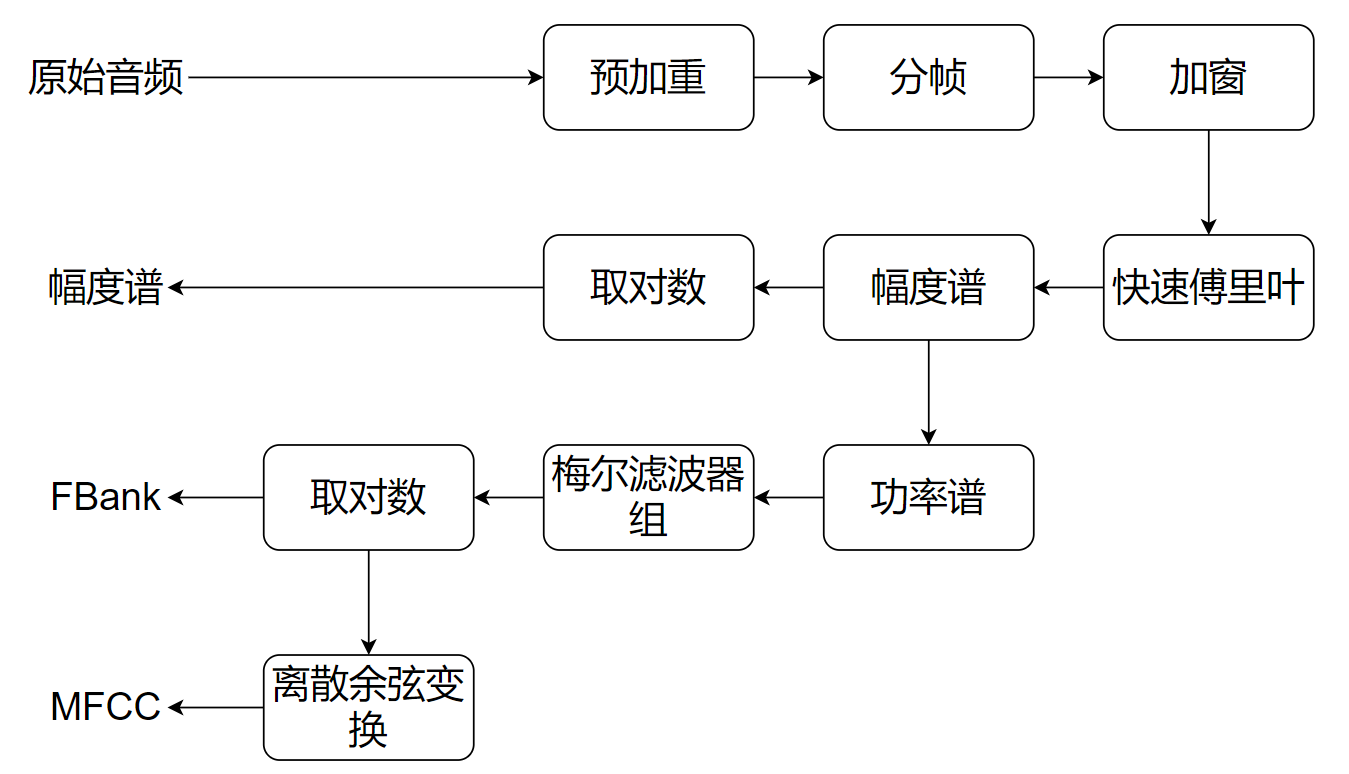 


### 课程二（30%）

自行构建幅度谱

##### 1.librosa加载音频

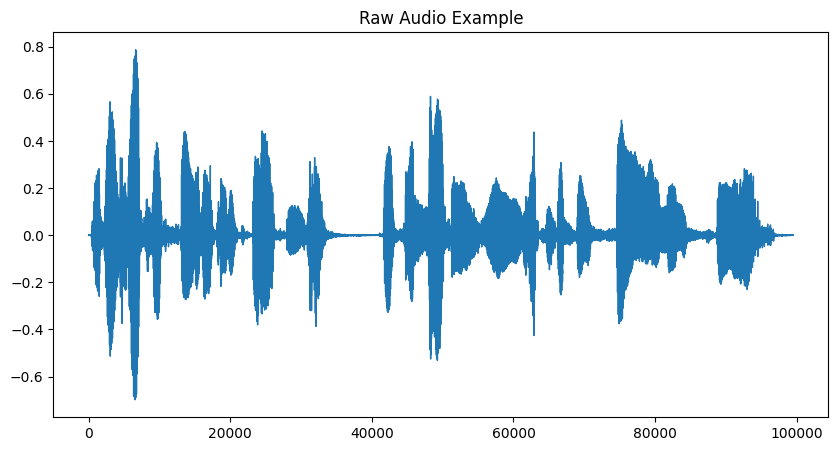

In [9]:
audio_file = 'LJ001-0011.wav'
ipd.Audio(audio_file)
data, sr = librosa.load(audio_file)
pd.Series(data).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw Audio Example')
plt.show()

##### 2.实现预加重函数
预加重处理相当于将语音信号通过一个高通滤波器，用来提升高频部分，因为语音信号的高频能量通常较低，预加重可以平衡频谱，便于后续分析。

y[t]=x[t]−α⋅x[t−1]

α通常取0.97

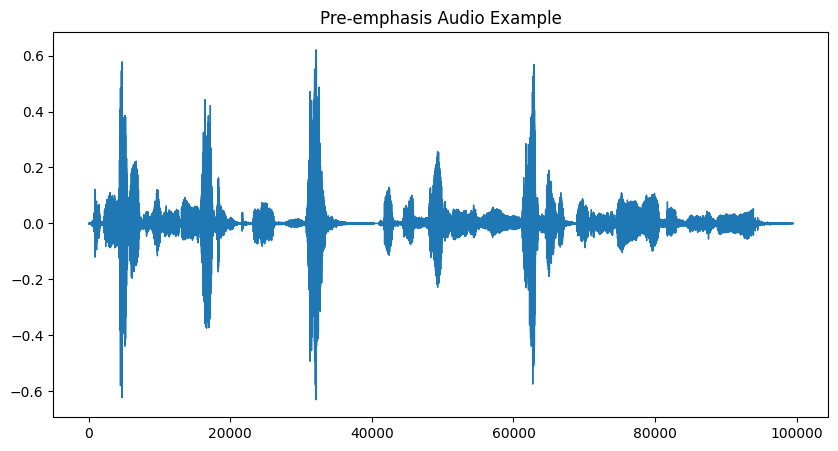

In [10]:
def pre_emphasis(sig, alpha=0.97):
    """
    function:预加重
    para: sig:要进行处理的音频数据
    return 进行加强处理后的音频数据
    """
        # TODO：实现预加重函数
    sig = np.asarray(sig, dtype=np.float32)
    if sig.ndim != 1:
        sig = sig.reshape(-1)
    emphasized = np.empty_like(sig)
    emphasized[0] = sig[0]
    emphasized[1:] = sig[1:] - alpha * sig[:-1]
    return emphasized

step1 = pre_emphasis(data)
pd.Series(step1).plot(figsize=(10, 5),
                  lw=1,
                  title='Pre-emphasis Audio Example')
plt.show()

#观察对比预加重处理前后的音频图像，图像的哪些特征反应了预加重处理的效果？

##### 问题回答：预加重前后图像对比
- 预加重后，波形中的快速变化（高频分量）会更加明显，表现为细节更“尖锐”、局部振荡幅度相对提升。
- 原始语音通常低频能量占主导，预加重后高频信息被增强，整体频谱斜率被拉平。
- 在后续幅度谱或梅尔谱中，常见现象是中高频区域能量相对抬升，更利于音素边界与辅音细节的分析。
- 这一步的本质是通过一阶高通形式 $y[t]=x[t]-\alpha x[t-1]$（通常 $\alpha=0.97$）补偿语音高频衰减。

##### 3.实现分帧函数

通常帧长25ms,帧位移10ms,为了确保所有帧采样数相等,需要对信号最后进行填充

查看分帧后的shape,分帧后shape变成二维

In [11]:
def framing(sig,fs,frame_len_s=0.025,frame_shift_s=0.01):
    """
    function：分帧
    para：
        frame_len_s:每一帧的长度,单位为s
        frame_shift_s:分帧的shift,单位为s
        fs：采样率，hz
        sig：要进行分帧的音频信号
    return：进行分帧后的数据，一个二维list，一个元素是一帧信号
    """
        # TODO：实现分帧函数
    sig = np.asarray(sig, dtype=np.float32).reshape(-1)
    frame_len = int(round(frame_len_s * fs))
    frame_shift = int(round(frame_shift_s * fs))

    if frame_len <= 0 or frame_shift <= 0:
        raise ValueError("frame_len 和 frame_shift 必须大于 0")

    sig_len = len(sig)
    if sig_len <= frame_len:
        num_frames = 1
    else:
        num_frames = int(np.ceil((sig_len - frame_len) / frame_shift)) + 1

    pad_len = (num_frames - 1) * frame_shift + frame_len
    pad_sig = np.pad(sig, (0, pad_len - sig_len), mode="constant")

    indices = (
        np.tile(np.arange(frame_len), (num_frames, 1))
        + np.tile(np.arange(0, num_frames * frame_shift, frame_shift), (frame_len, 1)).T
    )
    frames = pad_sig[indices]
    return frames

step2 = framing(step1,sr)
print(step2.shape)

(451, 551)


##### 4.实现加窗函数

hamming窗提示:numpy.hamming()

加窗方式:frame_sig_window(n)=frame_sig(n)⋅window(n)

In [12]:
#Xw(n)=X(n)⋅w(n)
def add_window(frame_sig,fs,frame_len_s=0.025):
    """
    function：加窗
    para：
        frame_len_s：每一帧的长度,单位为s
        fs：采样率
        frame_sig:进行分帧后的数据
    return：加窗后的数据
    """
        # TODO：实现加窗函数（使用hamming窗）
    frame_sig = np.asarray(frame_sig, dtype=np.float32)
    if frame_sig.ndim == 1:
        frame_sig = frame_sig.reshape(1, -1)

    frame_len = int(round(frame_len_s * fs))
    if frame_len <= 0:
        raise ValueError("frame_len 必须大于 0")

    # 以实际帧长为准，避免与上一步分帧长度不一致
    if frame_len != frame_sig.shape[1]:
        frame_len = frame_sig.shape[1]

    window = np.hamming(frame_len).astype(np.float32)
    frame_sig_window = frame_sig * window[np.newaxis, :]
    return frame_sig_window

step3 = add_window(step2,sr)
step3.shape

# 实际上加窗不止有汉明窗，还有其他窗函数，问问大模型，还有哪些窗函数？让他帮你实现其中一个，最后看看不同窗函数的幅度谱图有什么区别。

(451, 551)

##### 问题回答：除了 Hamming 还有哪些窗函数？区别是什么？
常见窗函数包括：
- 矩形窗（Rectangular）
- 汉宁窗（Hann）
- 布莱克曼窗（Blackman）
- Kaiser 窗（可调参数 $\beta$）
- Bartlett（三角窗）
对幅度谱的影响（核心是主瓣宽度与旁瓣抑制的权衡）：
- Hamming：旁瓣抑制较好，泄漏较小，语音处理中很常用。
- Hann：与 Hamming 接近，但主瓣略宽、旁瓣特性略有差异。
- Blackman：旁瓣抑制更强、谱泄漏更小，但主瓣更宽，频率分辨率会下降。
- Rectangular：主瓣最窄（分辨率高），但旁瓣高、泄漏明显。
实验上若切换窗函数，通常会观察到：
- 泄漏小的窗（如 Blackman）频谱更“干净”；
- 主瓣窄的窗（如矩形窗）细节更尖锐但伪峰可能更多。

##### 5.实现短时傅里叶变换函数得到幅度谱

nfft通常为256或512

STFT提示:numpy.fft.rfft()

幅度谱需要取模

In [13]:
def stft(frame_sig, nfft=512):    
    """
    function：短时傅里叶变换将帧信号变为帧功率（对应幅值频发）
    para：
        frame_sig: 分帧后的信号
        nfft: fft点数
    return: 返回分帧信号的幅度谱和功率谱
    """
    frame_sig = np.asarray(frame_sig, dtype=np.float32)
    if frame_sig.ndim == 1:
        frame_sig = frame_sig.reshape(1, -1)

    # TODO：得到幅度谱
    frame_fft = np.fft.rfft(frame_sig, n=nfft, axis=1)
    frame_mag = np.abs(frame_fft)

    # 功率谱
    frame_pow = (frame_mag ** 2) * 1.0 / nfft # 取平方 
    return frame_mag,frame_pow

frame_mag, step4 = stft(step3) 
frame_mag.shape

(451, 257)

##### 6.取对数得到可绘制查看的幅度谱,并绘制

$F_{\text{dB}} = 20 \times \log_{10} (F)$

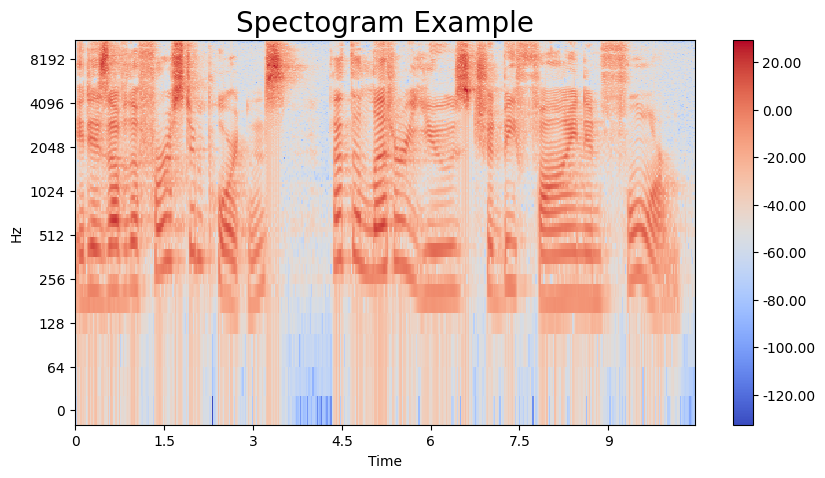

In [14]:
frame_log = 20 * np.log10(frame_mag)
fig, ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(frame_log.T,
                              x_axis='time',
                              y_axis='log',
                              ax=ax)
ax.set_title('Spectogram Example', fontsize=20)
fig.colorbar(img, ax=ax, format=f'%0.2f')
plt.show()

### 课程三 （45%）

实现FBank和MFCC

##### 1.实现mel滤波
人耳对低频更敏感,但对高频变化的分辨率较低,所以要使用Mel频率刻度来更符合人耳的听觉特性.

奈奎斯特采样定理:当采样频率fs.max大于信号中最高频率fmax的2倍时(fs.max>2fmax)，采样之后的数字信号完整地保留了原始信号中的信息。

$n_{\text{filter}}$取40, nfft取512

$M_{\text{min}} = 0$

$M_{\text{max}} = 2595 \log_{10} \left( 1 + \frac{fs}{2 \times 700} \right)$

$M_i = \text{linspace}(M_{\text{min}}, M_{\text{max}}, n_{\text{filter}} + 2)$

$f_i = 700 \left(10^{M_i / 2595} - 1 \right)$

$H_m(k) =
\begin{cases}
  0, & k < f(m-1) \text{ or } k > f(m+1) \\
  \frac{k - f(m-1)}{f(m) - f(m-1)}, & f(m-1) \leq k \leq f(m) \\
  \frac{f(m+1) - k}{f(m+1) - f(m)}, & f(m) < k \leq f(m+1)
\end{cases}$

$\text{filter\_banks} = P \cdot H_m^T$

查看最后维度

In [15]:
def mel_filter(frame_pow, fs, n_filter=40, nfft=512):    
    """
    function:mel 滤波器系数计算
    para:
        frame_pow: 分帧信号功率谱
        fs: 采样率 hz
        n_filter: 滤波器个数
        nfft: fft点数
    return: 分帧信号功率谱mel滤波后的值的对数值
    mel = 2595 * log10(1 + f/700) # 频率到mel值映射
    f = 700 * (10^(m/2595) - 1 # mel值到频率映射
    上述过程本质上是对频率f对数化
    """
    frame_pow = np.asarray(frame_pow, dtype=np.float32)
    if frame_pow.ndim == 1:
        frame_pow = frame_pow.reshape(1, -1)

    mel_min = 0 # 最低mel值
    mel_max = 2595 * np.log10(1 + (fs / 2) / 700) # 最高mel值，最大信号频率为 fs/2
    mel_points = np.linspace(mel_min, mel_max, n_filter + 2)
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)
    filter_edge = np.floor(hz_points * (nfft + 1) / fs).astype(int) # 对应到fft的点数比例上

    fbank = np.zeros((n_filter, int(nfft / 2 + 1)), dtype=np.float32)
    # TODO:求mel滤波器系数
    for m in range(1, n_filter + 1):
        left = filter_edge[m - 1]
        center = filter_edge[m]
        right = filter_edge[m + 1]

        if center == left:
            center += 1
        if right == center:
            right += 1

        for k in range(left, center):
            if 0 <= k < fbank.shape[1]:
                fbank[m - 1, k] = (k - left) / (center - left)
        for k in range(center, right):
            if 0 <= k < fbank.shape[1]:
                fbank[m - 1, k] = (right - k) / (right - center)
    
    # TODO:mel 滤波
    # 提示：[num_frame, nfft/2 + 1] * [nfft/2 + 1, n_filter] = [num_frame, n_filter]
    filter_banks = np.dot(frame_pow, fbank.T)

    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)
    # np.finfo函数是根据括号中的类型来获得信息，获得符合这个类型的数型, eps是取非负的最小值
    return filter_banks
step5 = mel_filter(step4, sr) 
print(step5.shape)

(451, 40)


##### 3.取对数得到可绘制查看的梅尔谱,并绘制,注意矩阵维度,可能需要转置

$P_{\text{dB}} = 20 \times \log_{10} (P)$

In [16]:
fbank = 20 * np.log10(step5)
fbankT = fbank.T   # 方便可视化
print(fbankT.shape)

(40, 451)


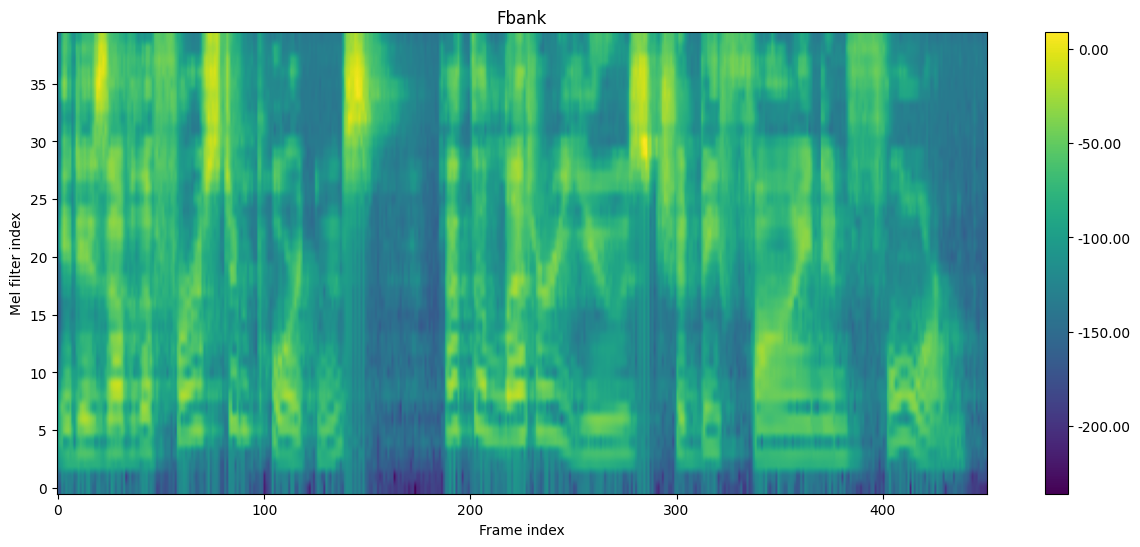

In [17]:
plt.figure(figsize=(15, 6))
plt.imshow(fbankT, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("Fbank")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

##### 4.使用fbank经过离散余弦变换函数得到mfcc,并绘图

In [18]:
from scipy.fftpack import dct
def discrete_cosine_transform(filter_banks):
    """
    function：离散余弦变换
    para：filter_banks:fbanks
    return: mfcc
    """
    filter_banks = np.asarray(filter_banks, dtype=np.float32)
    if filter_banks.ndim == 1:
        filter_banks = filter_banks.reshape(1, -1)

    num_ceps = 12
    # TODO: 离散余弦变换
    """
    scipy.fftpack.dct:返回任意类型序列x的离散余弦变换。
    """
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, :num_ceps]
    return mfcc
mfcc  = discrete_cosine_transform(fbank)
mfcc.shape

(451, 12)

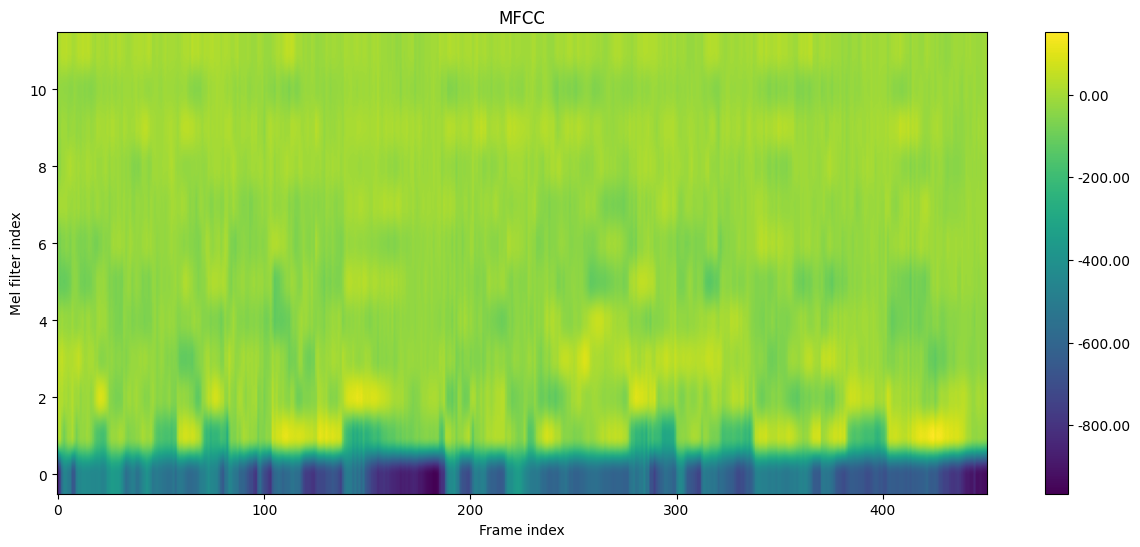

In [19]:
plt.figure(figsize=(15, 6))
plt.imshow(mfcc.T, origin='lower', aspect='auto')
plt.colorbar(format='%0.2f')
plt.title("MFCC")
plt.xlabel("Frame index")
plt.ylabel("Mel filter index")
plt.show()

### 课程四（加分项：10%）
           

基于预训练模型的深度音频特征提取

在前面的实验中，你已经学会了如何手动提取传统的音频特征（MFCC、FBank）。近年来，基于深度学习的预训练模型（如 **Wav2Vec2、HuBERT、Whisper**）可以从音频中自动学习到更强大的特征表示，广泛应用于语音识别、说话人识别等任务。本实验需要你加载一个预训练的 **Wav2Vec2** 或**HuBERT**模型（二选一），用它来提取示例音频LJ001-0011.wav的深度特征。

Wav2Vec2模型：

torchaudio文档：https://docs.pytorch.org/audio/stable/generated/torchaudio.models.Wav2Vec2Model.html

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/wav2vec2

HuBERT模型：

github仓库：https://github.com/facebookresearch/fairseq/tree/main/examples/hubert

Hugging Face Transformers文档：https://huggingface.co/docs/transformers/model_doc/hubert

注：HuBERT和Wav2Vec2模型对于输入音频的采样率均有要求，你可能需要对音频进行重采样以符合模型的要求。

采样率: 16000
波形形状: (1, 72189)
音频时长: 4.512 s
深度特征形状 [帧数, 维度]: (225, 768)
按模型步长估算帧数: 225.6
特征统计: min=-4.6607, max=4.2757, mean=-0.0020, std=0.3121
是否存在 NaN: False


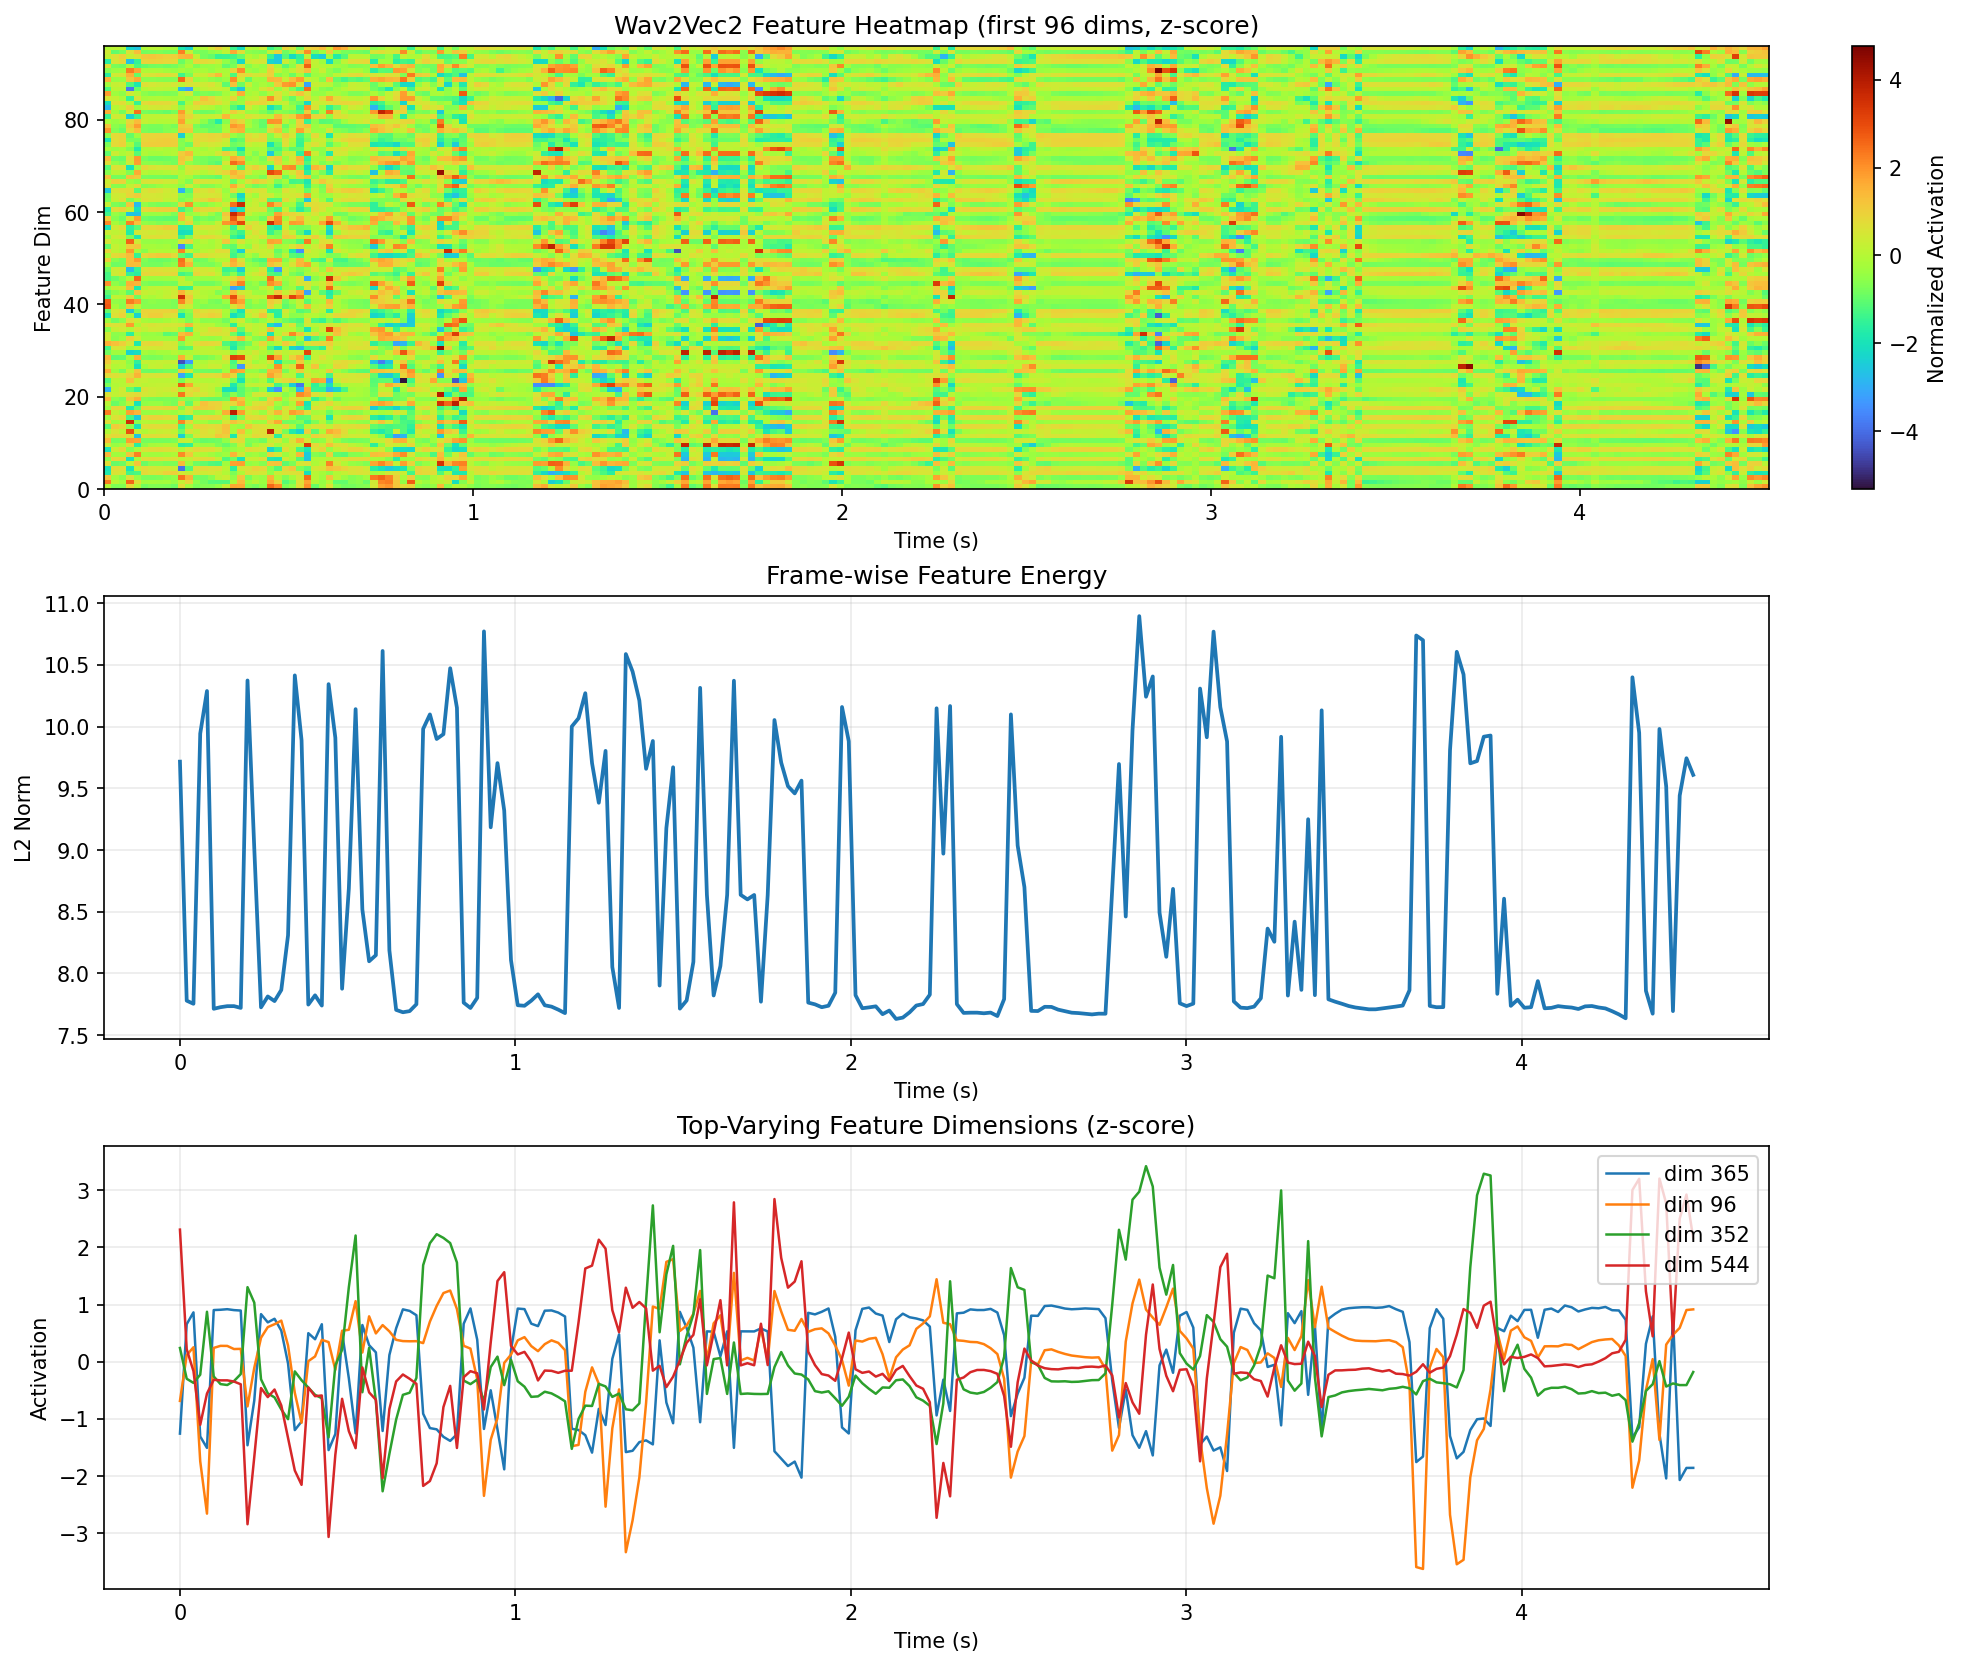

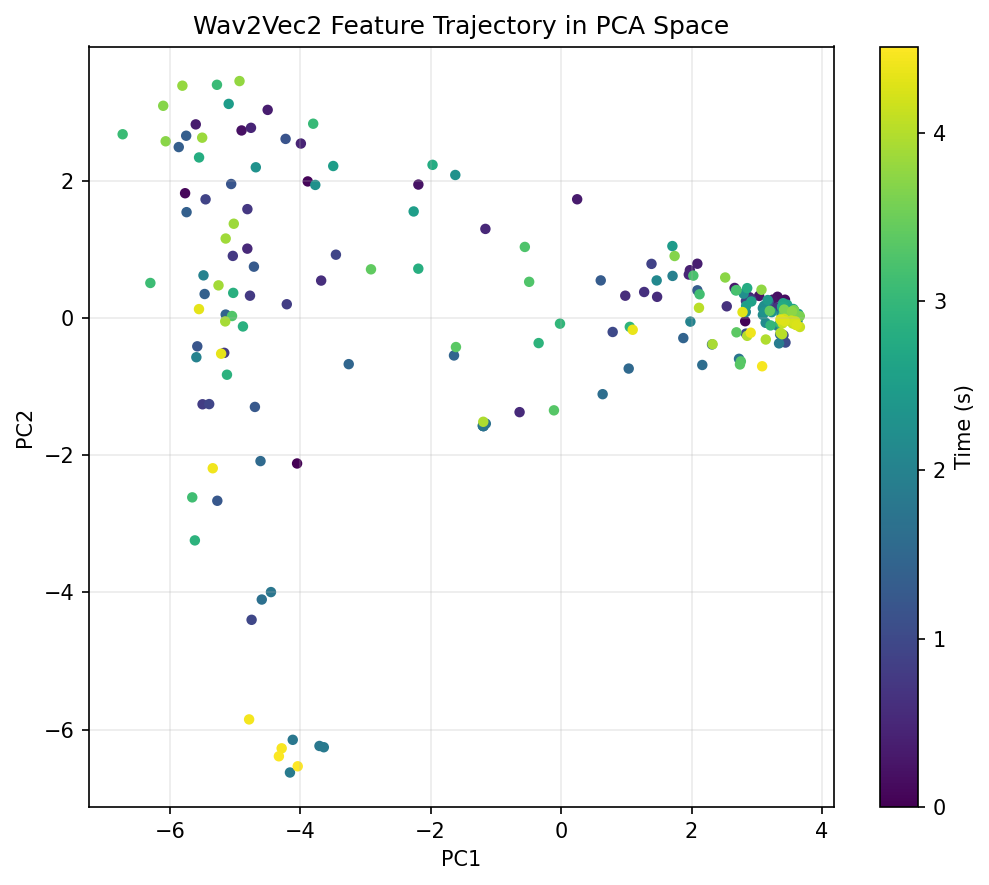

解释提示：
1) 热力图里亮暗带随时间变化，表示不同特征维在不同时间段被激活。
2) 帧能量峰值通常对应发音更强或音素转换更明显的片段。
3) PCA 轨迹若连续平滑，说明特征随语音时序稳定演化；若突变，常对应音素边界。


In [2]:
import os
import numpy as np
import torch
import torchaudio
import matplotlib.pyplot as plt

# 1) 读取音频
wav_path = "LJ001-0011.wav"
if not os.path.exists(wav_path):
    raise FileNotFoundError(f"找不到音频文件: {wav_path}")

waveform, sr = torchaudio.load(wav_path)  # [channel, num_samples]
if waveform.size(0) > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

# 2) 重采样到 16kHz（Wav2Vec2 要求）
target_sr = 16000
if sr != target_sr:
    resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
    waveform = resampler(waveform)
    sr = target_sr

# 3) 提取 Wav2Vec2 深度特征
bundle = torchaudio.pipelines.WAV2VEC2_BASE
model = bundle.get_model()
model.eval()

with torch.inference_mode():
    layer_features, _ = model.extract_features(waveform)

deep_feat = layer_features[-1].squeeze(0).cpu().numpy()  # [T, D]

# 4) 基础正确性检查
duration_sec = waveform.shape[1] / sr
expected_frames = duration_sec * (sr / 320)  # 约 50 fps

print(f"采样率: {sr}")
print(f"波形形状: {tuple(waveform.shape)}")
print(f"音频时长: {duration_sec:.3f} s")
print(f"深度特征形状 [帧数, 维度]: {deep_feat.shape}")
print(f"按模型步长估算帧数: {expected_frames:.1f}")
print(f"特征统计: min={deep_feat.min():.4f}, max={deep_feat.max():.4f}, mean={deep_feat.mean():.4f}, std={deep_feat.std():.4f}")
print(f"是否存在 NaN: {np.isnan(deep_feat).any()}")

# 5) 可解释化处理
T, D = deep_feat.shape
time_axis = np.linspace(0, duration_sec, T)

# 每维标准化，便于横向比较
feat_z = (deep_feat - deep_feat.mean(axis=0, keepdims=True)) / (deep_feat.std(axis=0, keepdims=True) + 1e-6)

# (a) 热力图：展示前 96 维
show_dim = min(96, D)
heat = feat_z[:, :show_dim]

# (b) 帧能量曲线：看整体语音强弱与结构变化
frame_energy = np.linalg.norm(deep_feat, axis=1)

# (c) 变化最明显的 4 个维度（按方差排序）
var_per_dim = deep_feat.var(axis=0)
topk = 4
top_idx = np.argsort(var_per_dim)[-topk:][::-1]

# (d) PCA 2D 轨迹（用 SVD 手工实现，避免额外依赖）
X = deep_feat - deep_feat.mean(axis=0, keepdims=True)
U, S, _ = np.linalg.svd(X, full_matrices=False)
pc = U[:, :2] * S[:2]

# 6) 绘图：三联图
fig, axes = plt.subplots(3, 1, figsize=(13, 11), dpi=150, constrained_layout=True)

im = axes[0].imshow(
    heat.T,
    aspect="auto",
    origin="lower",
    cmap="turbo",
    interpolation="nearest",
    extent=[0, duration_sec, 0, show_dim]
)
axes[0].set_title(f"Wav2Vec2 Feature Heatmap (first {show_dim} dims, z-score)")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Feature Dim")
fig.colorbar(im, ax=axes[0], label="Normalized Activation")

axes[1].plot(time_axis, frame_energy, lw=1.8)
axes[1].set_title("Frame-wise Feature Energy")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("L2 Norm")
axes[1].grid(alpha=0.25)

for d_idx in top_idx:
    axes[2].plot(time_axis, feat_z[:, d_idx], lw=1.2, label=f"dim {d_idx}")
axes[2].set_title("Top-Varying Feature Dimensions (z-score)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Activation")
axes[2].grid(alpha=0.25)
axes[2].legend(loc="upper right")

plt.show()

# 7) 再补一张 PCA 轨迹图（颜色表示时间）
plt.figure(figsize=(7, 6), dpi=150)
sc = plt.scatter(pc[:, 0], pc[:, 1], c=time_axis, s=16, cmap="viridis")
plt.colorbar(sc, label="Time (s)")
plt.title("Wav2Vec2 Feature Trajectory in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("解释提示：")
print("1) 热力图里亮暗带随时间变化，表示不同特征维在不同时间段被激活。")
print("2) 帧能量峰值通常对应发音更强或音素转换更明显的片段。")
print("3) PCA 轨迹若连续平滑，说明特征随语音时序稳定演化；若突变，常对应音素边界。")

===== 深度特征可读摘要 =====
总时长: 4.512s, 帧数: 225, 维度: 768
显著变化点数量(去重后): 10
显著变化时刻(秒):
[0.101 0.201 1.571 1.652 1.873 3.142 3.303 3.726 4.331 4.451]


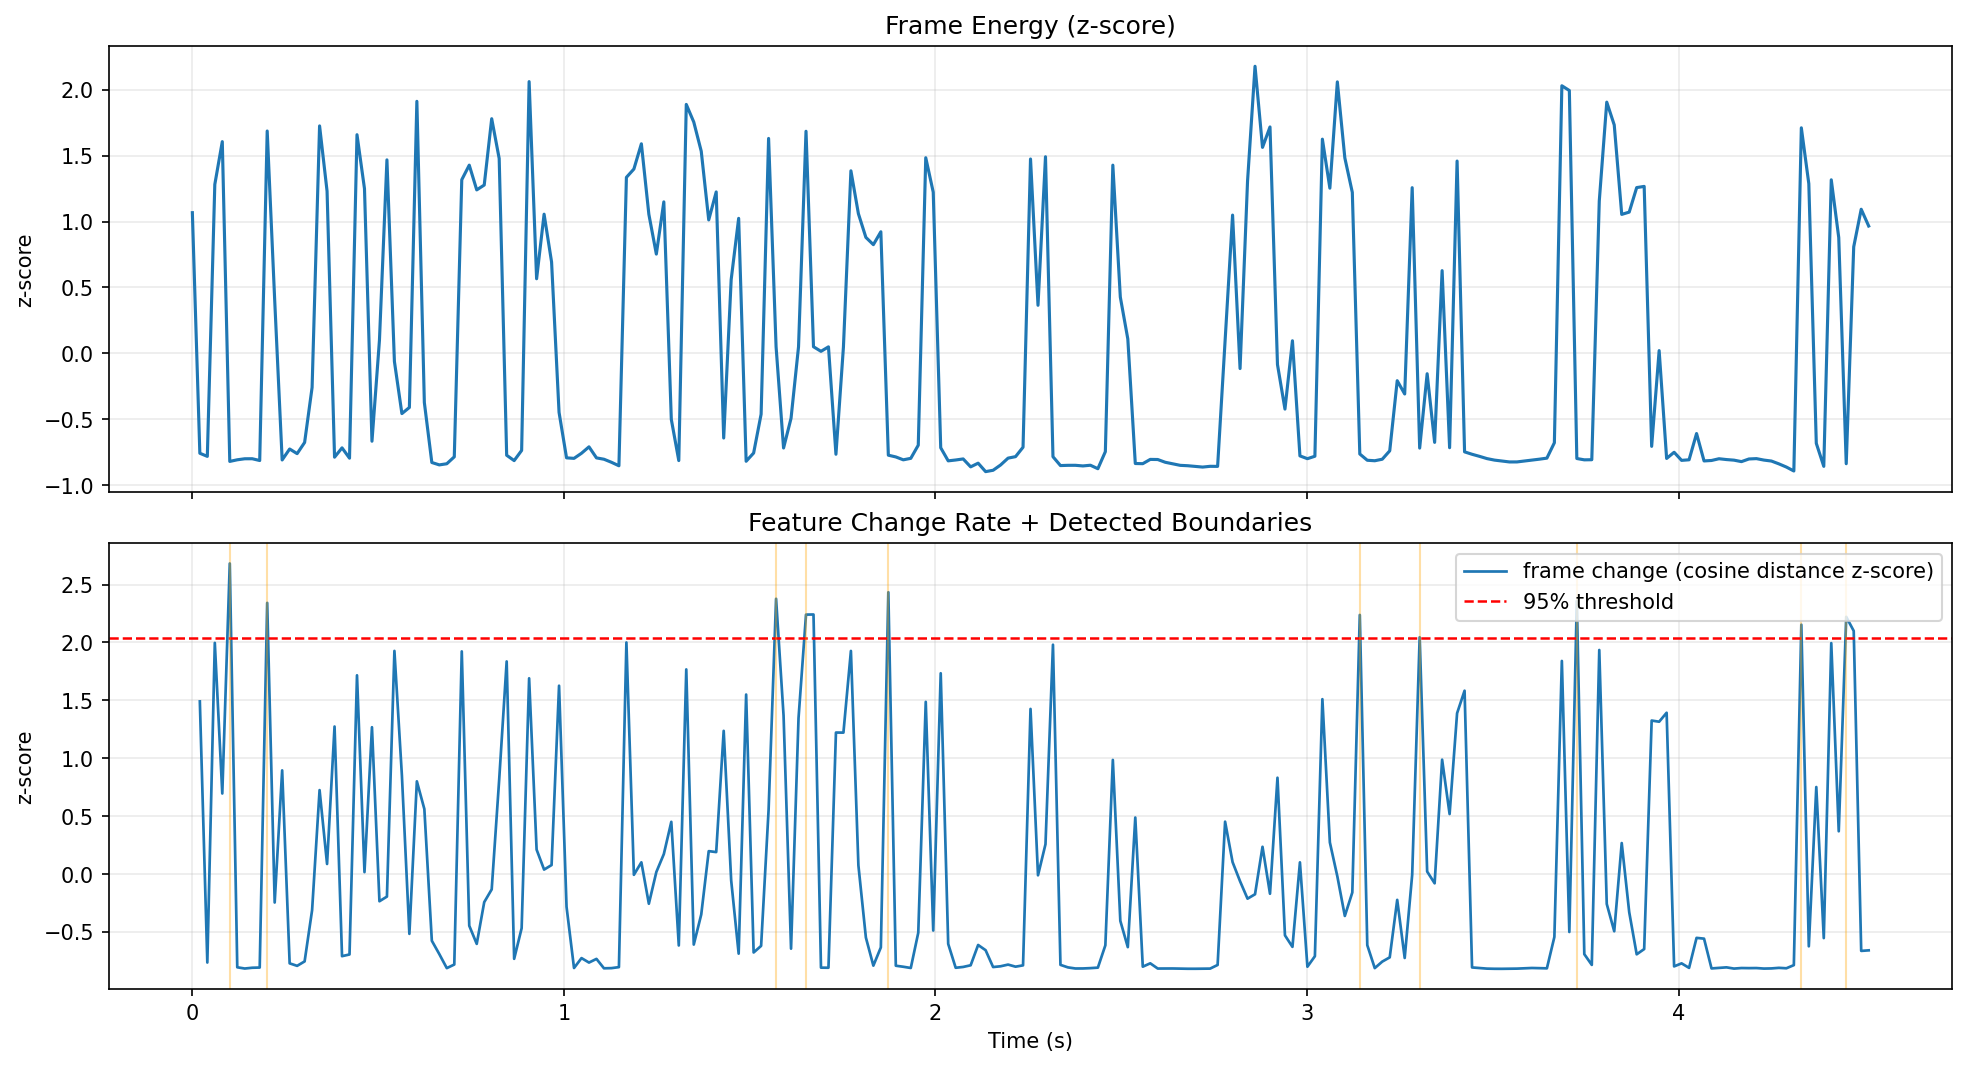

In [4]:
# 可读结果摘要：把深度特征转成“时间事件”
# 依赖上一单元已得到的 deep_feat 和 duration_sec

T, D = deep_feat.shape
time_axis = np.linspace(0, duration_sec, T)

# 1) 帧能量（粗略反映语音强弱）
energy = np.linalg.norm(deep_feat, axis=1)
energy_z = (energy - energy.mean()) / (energy.std() + 1e-8)

# 2) 邻帧余弦距离（反映特征变化速度，越大越可能是音素边界/转折）
X = deep_feat / (np.linalg.norm(deep_feat, axis=1, keepdims=True) + 1e-8)
cos_sim = np.sum(X[1:] * X[:-1], axis=1)
cos_dist = 1.0 - cos_sim
change_z = (cos_dist - cos_dist.mean()) / (cos_dist.std() + 1e-8)

# 阈值：95 分位作为显著变化点
thr = np.percentile(change_z, 95)
change_idx = np.where(change_z >= thr)[0] + 1  # +1 对齐到后一帧
change_times = time_axis[change_idx]

# 去重：相邻太近( <80ms )的峰只保留一个，避免密集重复
selected = []
for i in change_idx:
    if len(selected) == 0 or (time_axis[i] - time_axis[selected[-1]]) >= 0.08:
        selected.append(i)
selected = np.array(selected, dtype=int)
selected_times = time_axis[selected]

# 输出文本摘要
print("===== 深度特征可读摘要 =====")
print(f"总时长: {duration_sec:.3f}s, 帧数: {T}, 维度: {D}")
print(f"显著变化点数量(去重后): {len(selected)}")
print("显著变化时刻(秒):")
print(np.round(selected_times, 3))

# 3) 可视化：能量 + 变化率，并标边界
fig, axes = plt.subplots(2, 1, figsize=(13, 7), dpi=150, sharex=True, constrained_layout=True)

axes[0].plot(time_axis, energy_z, lw=1.5)
axes[0].set_title("Frame Energy (z-score)")
axes[0].set_ylabel("z-score")
axes[0].grid(alpha=0.25)

axes[1].plot(time_axis[1:], change_z, lw=1.3, label="frame change (cosine distance z-score)")
axes[1].axhline(thr, color="r", ls="--", lw=1.2, label="95% threshold")
for t in selected_times:
    axes[1].axvline(t, color="orange", alpha=0.35, lw=1)
axes[1].set_title("Feature Change Rate + Detected Boundaries")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("z-score")
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper right")

plt.show()

##### 加分实验思考（Wav2Vec2 深度特征）
1. 正确性与可用性
- 提取得到的特征维度为 $225\times768$，与模型输出结构一致。
- 帧数与音频时长匹配（约 $50$ 帧/秒），说明重采样与前向流程正确。
2. 结果可解释性
- 热力图显示不同特征维在时间轴上激活模式不同，说明模型学习到了时序相关表示。
- 帧能量曲线可反映发音强弱变化；变化率峰值可作为候选音素边界。
- PCA 轨迹整体连续，表明语音表示随时间平滑演化；局部突变对应语音单元切换。
3. 与传统特征（FBank/MFCC）对比
- MFCC/FBank 可解释性强、维度低、计算轻量。
- Wav2Vec2 特征表达能力更强，能编码更丰富上下文信息，但维度更高、计算开销更大。
4. 局限与改进方向
- 深度特征本身不直接给出文本语义，若要识别内容需结合 ASR 解码头。
- 本实验仅分析单条语音，后续可在多说话人、多噪声条件下比较鲁棒性。
- 可进一步尝试 HuBERT 或 Whisper 编码器，比较不同预训练模型的表征差异。